In [1]:
# Time series plots from Chris' compensated structure function files and profile files
# The code assumes the plot row number and column number is in the data file name (for the csf files) and the col number is in the profile file name
# Lisa Darby May 2026
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import StrMethodFormatter
# Plotting parameters
plt.rcParams['figure.dpi'] = 300
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.markersize'] = 3
plt.rcParams.update({'font.size': 18})

In [2]:
#Plot outfile name
plotfile_csf = 'C:/Users/lisad/OneDrive/Documents/bob_turb/test.jpg'

In [3]:
# Enter the time span for the upper right label
timespan = '2030 - 2130 UTC'

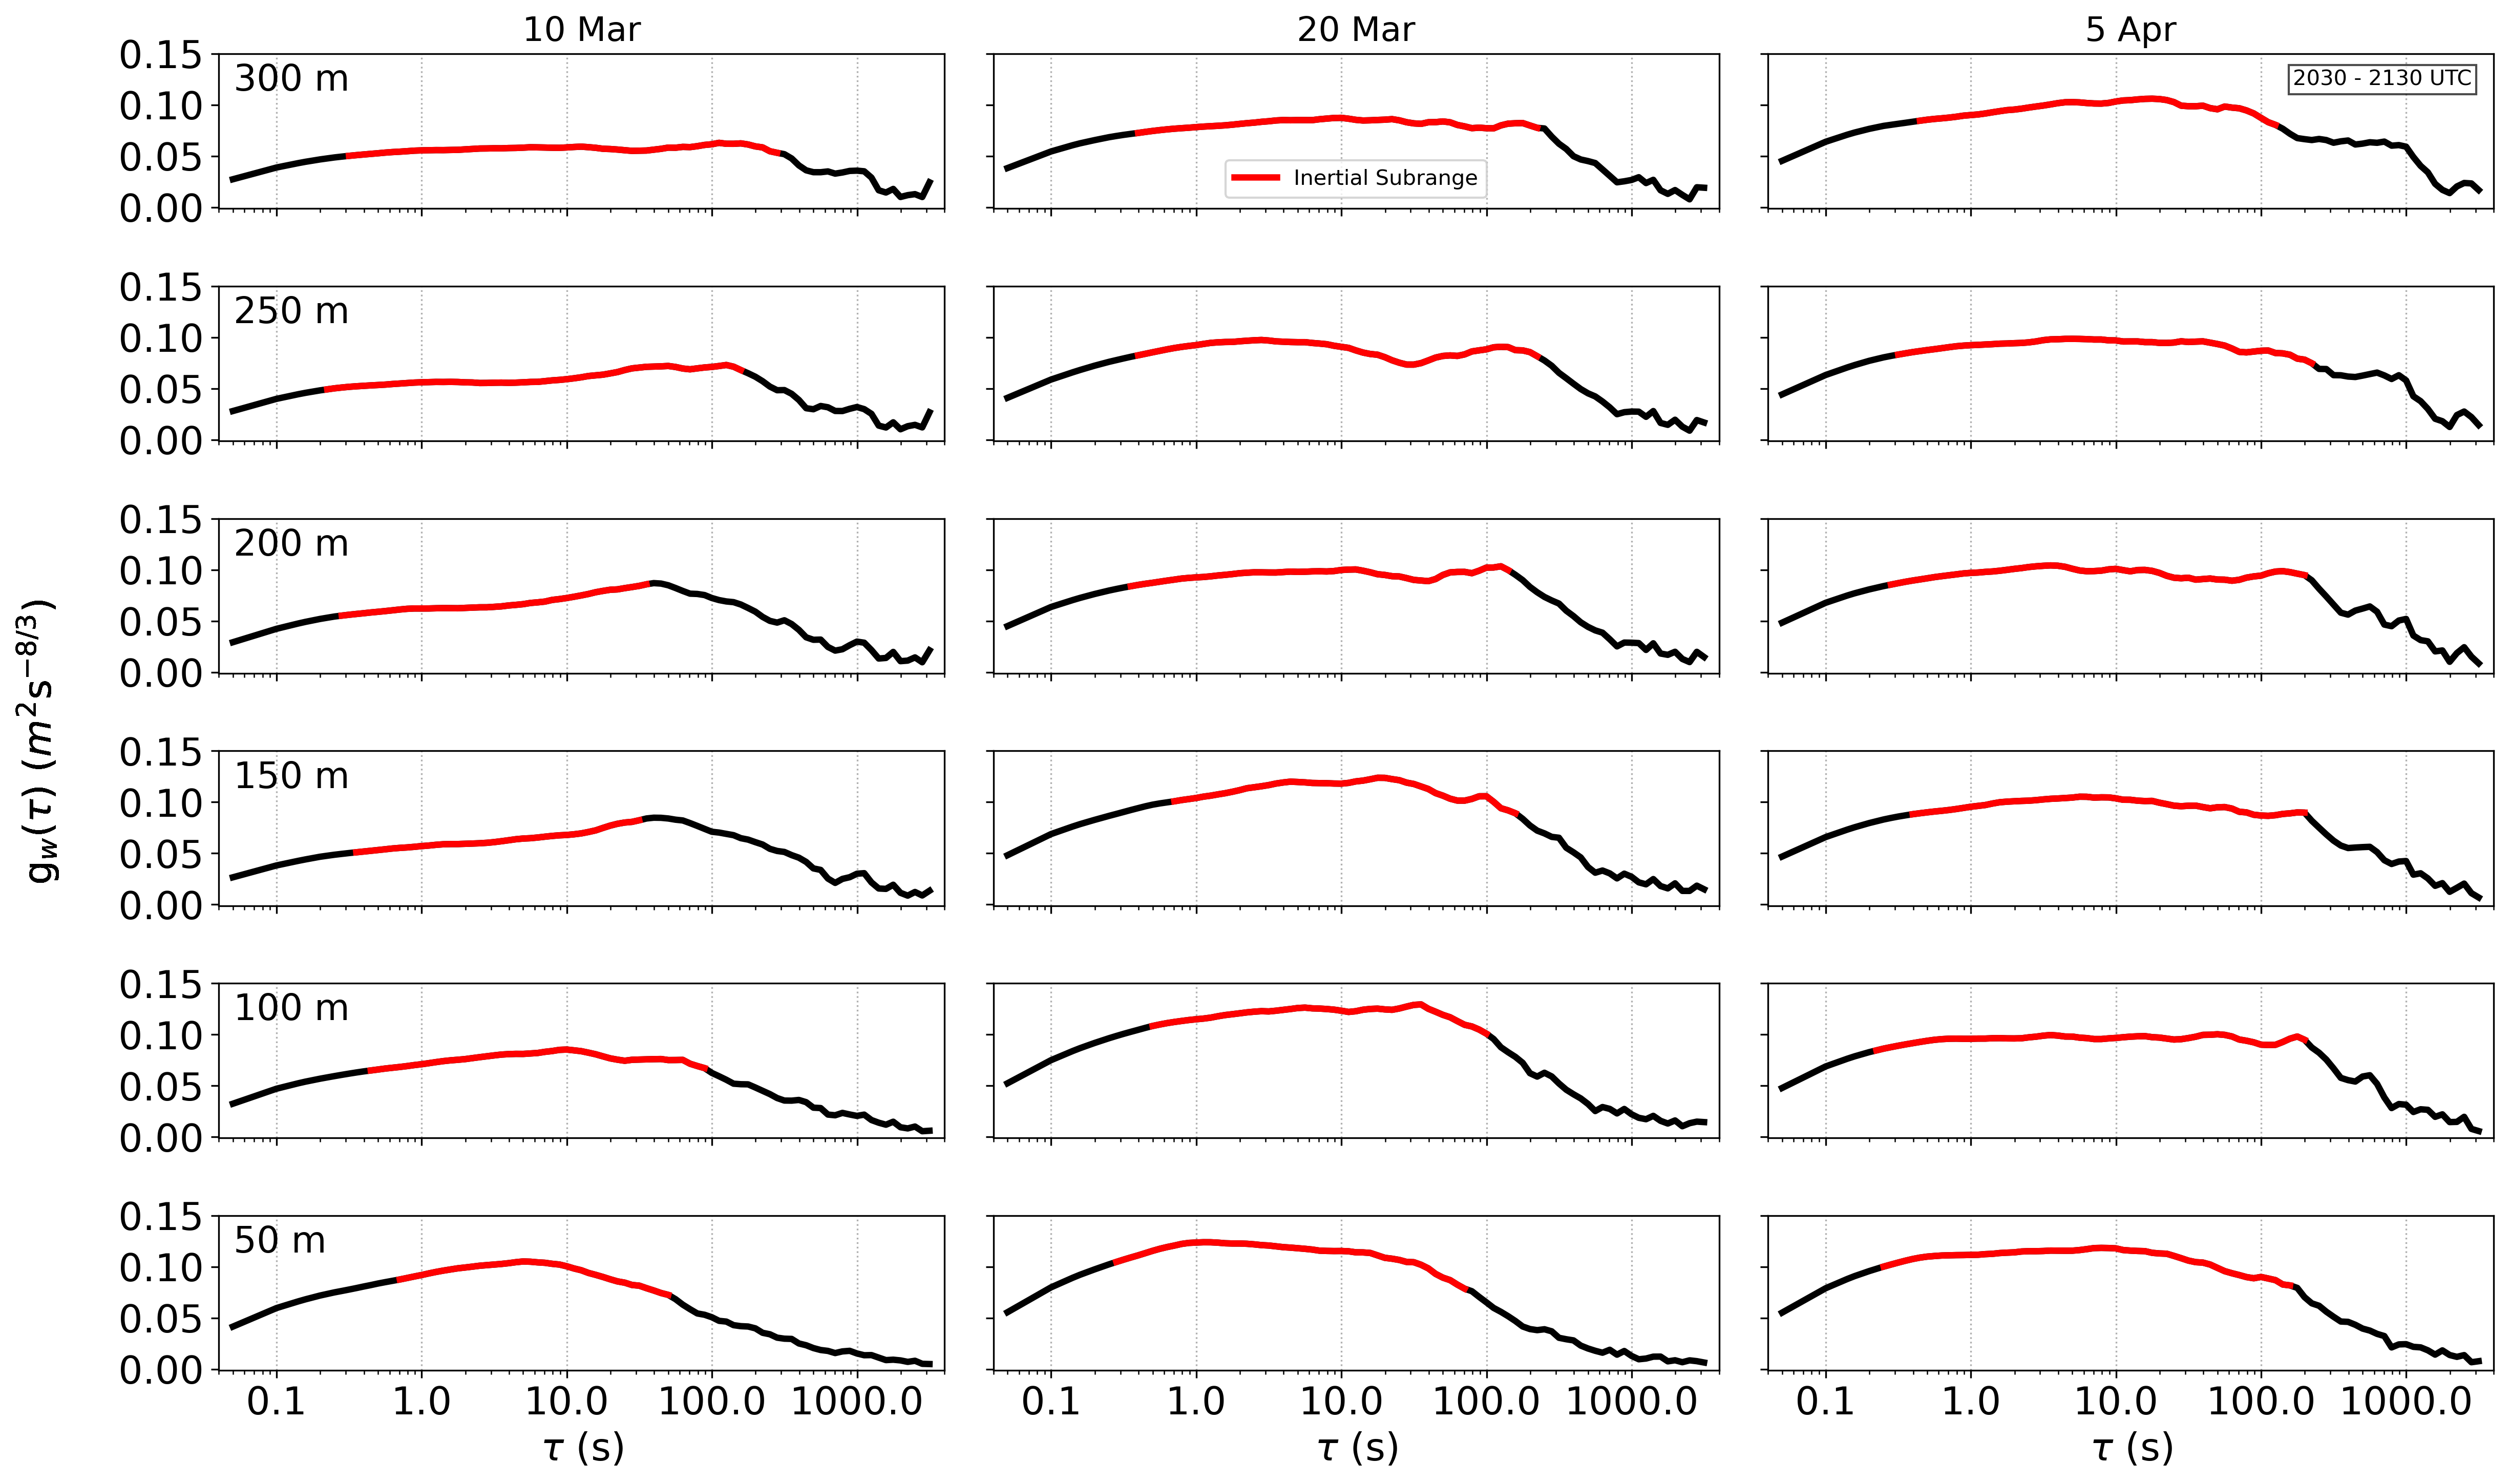

In [4]:
# For each plot, read in the data file with the compensated str fn and tau, and the corresponding profile plot to get
# the eddy min and mx
col_titles = ["10 Mar", "20 Mar", "5 Apr"]
row_labels = ['300 m', '250 m', '200 m','150 m','100 m','50 m']

# Plot the to_plot dataframe - compensated str fn
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(16, 10), sharex=True, sharey=True)

for r in range(6):
    for c in range(3):
        ax = axes[r, c]
        
        # data filenames (name has row and col numbers)
        filename = f"C:/Users/lisad/OneDrive/Documents/bob_turb/data/2030_2130/data_r{r}_c{c}.txt"

        # read in the data file and change the column names to something simple
        df = pd.read_fwf(filename, header=0)
        df.rename(columns={'tau_log,s': 'tau', 'csf_log,m2s-8/3': 'csf'}, inplace=True)
        to_plot = df

        # profile filenames (name has col number)
        filename_prof = f"C:/Users/lisad/OneDrive/Documents/bob_turb/data/2030_2130/data_inert_c{c}.txt" 
        
        # read in profile file and pluck out the min and max eddy sizes for each height
        df2 = pd.read_fwf(filename_prof, header=0)
        df2_reversed = df2[::-1].reset_index(drop=True) # flip df2 so last row is first (300 m is first)

        min_val = df2_reversed["min,s"].iloc[r]
        max_val = df2_reversed["max,s"].iloc[r]
        
        # Pluck out rows that correspond to the specified eddy size using the min and max obtained above, to overplot in red
        red_plot = df[df["tau"].between(min_val,max_val)]

        # create the plots
        line1, = ax.plot(to_plot['tau'], to_plot['csf'], color = 'black')
        line2, = ax.plot(red_plot['tau'], red_plot['csf'],color = 'red', label = 'Inertial Subrange')
        plt.xscale('log')
        plt.xlim(0.04, 4000)
        plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.1f}')) # x-axis in decimal format
        ax.yaxis.set_ticks(np.arange(0.0, .2, 0.05))
        ax.grid(axis = 'x', linestyle='dotted')

        # Titles only on top row
        if r == 0:
            ax.set_title(col_titles[c], fontsize=16)

        # X labels only on bottom row
        if r == 5:
            ax.set_xlabel(r'$\tau$ (s)')

        # add the legend that explains the red lines
        #if r == 0 and c == 0:                                          #2030 to 2130
            #ax.legend(handles=[line2], loc='upper right', fontsize=10) # 2030 to 2130
        if r == 0 and c == 1:                                         # 1930 to 2030
            ax.legend(handles=[line2], loc='lower center', fontsize=10)  # 1930 to 2030
            
        # Add one shared label in the middle left
        fig.text(-0.025, 0.5, r'g$_w$($\tau$) ($m^2$s$^{-8/3}$)', va='center', rotation='vertical')

        # Add height label to every plot in the first col
        if c == 0:
            ax.text(
                0.02, 0.94, row_labels[r],
                transform=ax.transAxes,
                ha='left', va='top',
                fontsize=17,
                bbox=dict(facecolor='white', alpha=0.0, edgecolor='none', pad=2)
            )

        if r == 0 and c == 2:
            ax.text(
                0.97, 0.9, timespan,
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=10,
                bbox=dict(facecolor='white', alpha=0.7, pad=2)
            )


plt.tight_layout()

fig.savefig(plotfile_csf, bbox_inches='tight')